In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Sensors_Data.csv")
df.head()

,Journal Link,TiC Mxene sensor,Functional Group,Response Time (in min),Current density (in μA/cm2),Detection Range (in M),Compound detected,EN of functional group,Atomic polarizability of functional group (in Å³),Mobility of functional group (in ×10⁻⁸ m²/V·s),Covalent Radii of functional group (in pm),Chemical formula of compound detected,N/O ratio,N/C ratio,C/H ratio,C/O ratio
0,https://www.sciencedirect.com/science/article/...,Graphene/TiC,–O,9.0,1480.000,5.55556*10-17 - 1.11111*10-8,Carcinoembryonic antigen(CEA),3.44,0.785,20.64,66.0,C3394H5266N930O1076S15,0.8643,0.2740,0.6445,3.1542
1,https://www.sciencedirect.com/science/article/...,Graphene/TiC,–NH2,9.0,1480.000,5.55556*10-17 - 1.11111*10-8,Carcinoembryonic antigen(CEA),3.04,1.096,7.62,71.0,C3394H5266N930O1076S15,0.8643,0.2740,0.6445,3.1542
2,https://www.sciencedirect.com/science/article/...,Graphene/TiC,–F,9.0,1480.000,5.55556*10-17 - 1.11111*10-8,Carcinoembryonic antigen(CEA),3.98,0.554,5.74,57.0,C3394H5266N930O1076S15,0.8643,0.2740,0.6445,3.1542
3,https://www.nature.com/articles/s41598-025-267...,PANI/TiC/Au,–NH–,NaN,452.707,7.03482*10-17 - 7.03482*10-14,Prostate-specific antigen (PSA),3.04,1.096,7.62,71.0,C1292H2020N352O361S15,0.9750,0.2724,0.6396,3.5789
4,https://www.mdpi.com/2079-6374/14/6/261,GO/TiC/CNT,–O,NaN,1775.700,10-6 - 9770*10-6,Hydrogen Peroxide (H2O2),3.44,0.785,20.64,66.0,H2O2,0.0000,NaN,0.0000,0.0000


In [3]:
det_col = "Detection Range (in M)"

# Split safely (handles NaN automatically)
ranges = df[det_col].astype(str).str.split(" - ", expand=True)

# If split fails, fill with NaN
ranges = ranges.reindex(columns=[0,1])

# Convert scientific format properly
min_vals = (ranges[0]
            .str.replace("*10-", "e-", regex=False)
            .str.replace("*10", "e", regex=False)
            .str.replace("10-", "1e-", regex=False)
           )

max_vals = (ranges[1]
            .str.replace("*10-", "e-", regex=False)
            .str.replace("*10", "e", regex=False)
            .str.replace("10-", "1e-", regex=False)
           )

# Convert to numeric safely (invalid values → NaN)
min_vals = pd.to_numeric(min_vals, errors='coerce')
max_vals = pd.to_numeric(max_vals, errors='coerce')

# Compute log detection range safely
log_range = np.log10(max_vals / min_vals)
df["Log_Detection_Range"] = log_range

In [4]:
# Remove column if already present
df.drop(columns=["Log_Detection_Range"], errors="ignore", inplace=True)

# Find position of Detection Range column
col_index = df.columns.get_loc("Detection Range (in M)")

# Insert immediately after it
df.insert(col_index + 1, "Log_Detection_Ratio", log_range)

In [5]:
df.head()

,Journal Link,TiC Mxene sensor,Functional Group,Response Time (in min),Current density (in μA/cm2),Detection Range (in M),Log_Detection_Ratio,Compound detected,EN of functional group,Atomic polarizability of functional group (in Å³),Mobility of functional group (in ×10⁻⁸ m²/V·s),Covalent Radii of functional group (in pm),Chemical formula of compound detected,N/O ratio,N/C ratio,C/H ratio,C/O ratio
0,https://www.sciencedirect.com/science/article/...,Graphene/TiC,–O,9.0,1480.000,5.55556*10-17 - 1.11111*10-8,8.301029,Carcinoembryonic antigen(CEA),3.44,0.785,20.64,66.0,C3394H5266N930O1076S15,0.8643,0.2740,0.6445,3.1542
1,https://www.sciencedirect.com/science/article/...,Graphene/TiC,–NH2,9.0,1480.000,5.55556*10-17 - 1.11111*10-8,8.301029,Carcinoembryonic antigen(CEA),3.04,1.096,7.62,71.0,C3394H5266N930O1076S15,0.8643,0.2740,0.6445,3.1542
2,https://www.sciencedirect.com/science/article/...,Graphene/TiC,–F,9.0,1480.000,5.55556*10-17 - 1.11111*10-8,8.301029,Carcinoembryonic antigen(CEA),3.98,0.554,5.74,57.0,C3394H5266N930O1076S15,0.8643,0.2740,0.6445,3.1542
3,https://www.nature.com/articles/s41598-025-267...,PANI/TiC/Au,–NH–,NaN,452.707,7.03482*10-17 - 7.03482*10-14,3.000000,Prostate-specific antigen (PSA),3.04,1.096,7.62,71.0,C1292H2020N352O361S15,0.9750,0.2724,0.6396,3.5789
4,https://www.mdpi.com/2079-6374/14/6/261,GO/TiC/CNT,–O,NaN,1775.700,10-6 - 9770*10-6,3.989895,Hydrogen Peroxide (H2O2),3.44,0.785,20.64,66.0,H2O2,0.0000,NaN,0.0000,0.0000


In [6]:
df = df.dropna(subset=['Functional Group'])

In [7]:
df.shape

(117, 17)

In [8]:
df['TiC Mxene sensor'] = df['TiC Mxene sensor'].str.strip('/')
df['Sensor_parts'] = df['TiC Mxene sensor'].str.split('/')

# Clean spaces
df['Sensor_parts'] = df['Sensor_parts'].apply(
    lambda x: [i.strip() for i in x if i.strip() != '']
)

In [9]:
from itertools import chain

unique_parts = sorted(set(chain.from_iterable(df['Sensor_parts'])))

# Assign codes as strings
component_map = {part: str(i) for i, part in enumerate(unique_parts)}

print(component_map)

{'Ag': '0', 'AlOOH': '1', 'Apt': '2', 'Au': '3', 'BN': '4', 'CNT': '5', 'COOH': '6', 'Carbon': '7', 'Cd': '8', 'CdS': '9', 'CeMOF': '10', 'Chit': '11', 'Co': '12', 'Co3O4': '13', 'Cu': '14', 'Cu2O': '15', 'CuMOF': '16', 'Fe': '17', 'GO': '18', 'Graphene': '19', 'IL': '20', 'L-Cyst': '21', 'MO': '22', 'Mn': '23', 'MnO2': '24', 'MoS2': '25', 'MoTiC': '26', 'N': '27', 'NH₂': '28', 'NH₂-UiO-66': '29', 'Nafion': '30', 'Ni': '31', 'NiO': '32', 'PANI': '33', 'PDA': '34', 'PEG': '35', 'PPY': '36', 'Pd': '37', 'Pt': '38', 'ReS2': '39', 'S': '40', 'SeS2': '41', 'TB': '42', 'Te': '43', 'TiAlC': '44', 'TiC': '45', 'TiO2': '46', 'UN': '47', 'V2O5': '48', 'aminosilane': '49'}


In [10]:
def encode_sensor(parts):
    codes = [component_map[p] for p in parts]
    return ''.join(sorted(codes))  # ensures consistency

In [11]:
df['Sensor_encoded'] = df['Sensor_parts'].apply(encode_sensor)

In [12]:
df['Sensor_encoded'] = df['Sensor_encoded'].astype(int)

In [13]:
df.drop(columns=['TiC Mxene sensor', 'Sensor_parts'], inplace=True)

In [14]:
df = pd.get_dummies(df, columns=['Functional Group'])

In [15]:
df.head()

,Journal Link,Response Time (in min),Current density (in μA/cm2),Detection Range (in M),Log_Detection_Ratio,Compound detected,EN of functional group,Atomic polarizability of functional group (in Å³),Mobility of functional group (in ×10⁻⁸ m²/V·s),Covalent Radii of functional group (in pm),...,C/H ratio,C/O ratio,Sensor_encoded,Functional Group_–F,Functional Group_–N,Functional Group_–NH2,Functional Group_–NH–,Functional Group_–O,Functional Group_–OH,Functional Group_═O
0,https://www.sciencedirect.com/science/article/...,9.0,1480.000,5.55556*10-17 - 1.11111*10-8,8.301029,Carcinoembryonic antigen(CEA),3.44,0.785,20.64,66.0,...,0.6445,3.1542,1945,False,False,False,False,True,False,False
1,https://www.sciencedirect.com/science/article/...,9.0,1480.000,5.55556*10-17 - 1.11111*10-8,8.301029,Carcinoembryonic antigen(CEA),3.04,1.096,7.62,71.0,...,0.6445,3.1542,1945,False,False,True,False,False,False,False
2,https://www.sciencedirect.com/science/article/...,9.0,1480.000,5.55556*10-17 - 1.11111*10-8,8.301029,Carcinoembryonic antigen(CEA),3.98,0.554,5.74,57.0,...,0.6445,3.1542,1945,True,False,False,False,False,False,False
3,https://www.nature.com/articles/s41598-025-267...,NaN,452.707,7.03482*10-17 - 7.03482*10-14,3.000000,Prostate-specific antigen (PSA),3.04,1.096,7.62,71.0,...,0.6396,3.5789,33345,False,False,False,True,False,False,False
4,https://www.mdpi.com/2079-6374/14/6/261,NaN,1775.700,10-6 - 9770*10-6,3.989895,Hydrogen Peroxide (H2O2),3.44,0.785,20.64,66.0,...,0.0000,0.0000,18455,False,False,False,False,True,False,False


In [16]:
df['Sensor_encoded']

0       1945
1       1945
2       1945
3      33345
4      18455
       ...  
132    36455
133    36455
134       45
135       45
136       45
Name: Sensor_encoded, Length: 117, dtype: int64

In [17]:
df.columns

Index(['Journal Link', 'Response Time (in min)', 'Current density (in μA/cm2)',
       'Detection Range (in M)', 'Log_Detection_Ratio', 'Compound detected',
       'EN of functional group ',
       'Atomic polarizability of functional group (in Å³)',
       'Mobility of functional group (in ×10⁻⁸ m²/V·s)',
       'Covalent Radii of functional group (in pm)',
       'Chemical formula of compound detected', 'N/O ratio', 'N/C ratio',
       'C/H ratio', 'C/O ratio', 'Sensor_encoded', 'Functional Group_–F',
       'Functional Group_–N', 'Functional Group_–NH2', 'Functional Group_–NH–',
       'Functional Group_–O', 'Functional Group_–OH', 'Functional Group_═O'],
      dtype='object')

In [18]:
df = df.drop(columns=[
    'Journal Link',
    'Response Time (in min)',
    'Compound detected',
    'Covalent Radii of functional group (in pm)',
    'N/O ratio',
    'N/C ratio'
])

In [19]:
df.head()

,Current density (in μA/cm2),Detection Range (in M),Log_Detection_Ratio,EN of functional group,Atomic polarizability of functional group (in Å³),Mobility of functional group (in ×10⁻⁸ m²/V·s),Chemical formula of compound detected,C/H ratio,C/O ratio,Sensor_encoded,Functional Group_–F,Functional Group_–N,Functional Group_–NH2,Functional Group_–NH–,Functional Group_–O,Functional Group_–OH,Functional Group_═O
0,1480.000,5.55556*10-17 - 1.11111*10-8,8.301029,3.44,0.785,20.64,C3394H5266N930O1076S15,0.6445,3.1542,1945,False,False,False,False,True,False,False
1,1480.000,5.55556*10-17 - 1.11111*10-8,8.301029,3.04,1.096,7.62,C3394H5266N930O1076S15,0.6445,3.1542,1945,False,False,True,False,False,False,False
2,1480.000,5.55556*10-17 - 1.11111*10-8,8.301029,3.98,0.554,5.74,C3394H5266N930O1076S15,0.6445,3.1542,1945,True,False,False,False,False,False,False
3,452.707,7.03482*10-17 - 7.03482*10-14,3.000000,3.04,1.096,7.62,C1292H2020N352O361S15,0.6396,3.5789,33345,False,False,False,True,False,False,False
4,1775.700,10-6 - 9770*10-6,3.989895,3.44,0.785,20.64,H2O2,0.0000,0.0000,18455,False,False,False,False,True,False,False


In [20]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [21]:
# Remove rows where Log_Detection_Ratio is inf or -inf
df = df[~np.isinf(df['Log_Detection_Ratio'])]

# Reset index
df = df.reset_index(drop=True)

In [22]:
# Shift to make all values positive before log
shift_value = abs(df['Current density (in μA/cm2)'].min()) + 1
df['Current density (in μA/cm2)'] = np.log1p(
    df['Current density (in μA/cm2)'] + shift_value
)

In [23]:
df.head()

,Current density (in μA/cm2),Detection Range (in M),Log_Detection_Ratio,EN of functional group,Atomic polarizability of functional group (in Å³),Mobility of functional group (in ×10⁻⁸ m²/V·s),Chemical formula of compound detected,C/H ratio,C/O ratio,Sensor_encoded,Functional Group_–F,Functional Group_–N,Functional Group_–NH2,Functional Group_–NH–,Functional Group_–O,Functional Group_–OH,Functional Group_═O
0,8.920255,5.55556*10-17 - 1.11111*10-8,8.301029,3.44,0.785,20.64,C3394H5266N930O1076S15,0.6445,3.1542,1945,0,0,0,0,1,0,0
1,8.920255,5.55556*10-17 - 1.11111*10-8,8.301029,3.04,1.096,7.62,C3394H5266N930O1076S15,0.6445,3.1542,1945,0,0,1,0,0,0,0
2,8.920255,5.55556*10-17 - 1.11111*10-8,8.301029,3.98,0.554,5.74,C3394H5266N930O1076S15,0.6445,3.1542,1945,1,0,0,0,0,0,0
3,8.772565,7.03482*10-17 - 7.03482*10-14,3.000000,3.04,1.096,7.62,C1292H2020N352O361S15,0.6396,3.5789,33345,0,0,0,1,0,0,0
4,8.959016,10-6 - 9770*10-6,3.989895,3.44,0.785,20.64,H2O2,0.0000,0.0000,18455,0,0,0,0,1,0,0


In [24]:
df = df.drop(columns=['Detection Range (in M)'])

In [25]:
df.dtypes

Current density (in μA/cm2)                          float64
Log_Detection_Ratio                                  float64
EN of functional group                               float64
Atomic polarizability of functional group (in Å³)    float64
Mobility of functional group (in ×10⁻⁸ m²/V·s)       float64
Chemical formula of compound detected                 object
C/H ratio                                            float64
C/O ratio                                            float64
Sensor_encoded                                         int64
Functional Group_–F                                    int64
Functional Group_–N                                    int64
Functional Group_–NH2                                  int64
Functional Group_–NH–                                  int64
Functional Group_–O                                    int64
Functional Group_–OH                                   int64
Functional Group_═O                                    int64
dtype: object

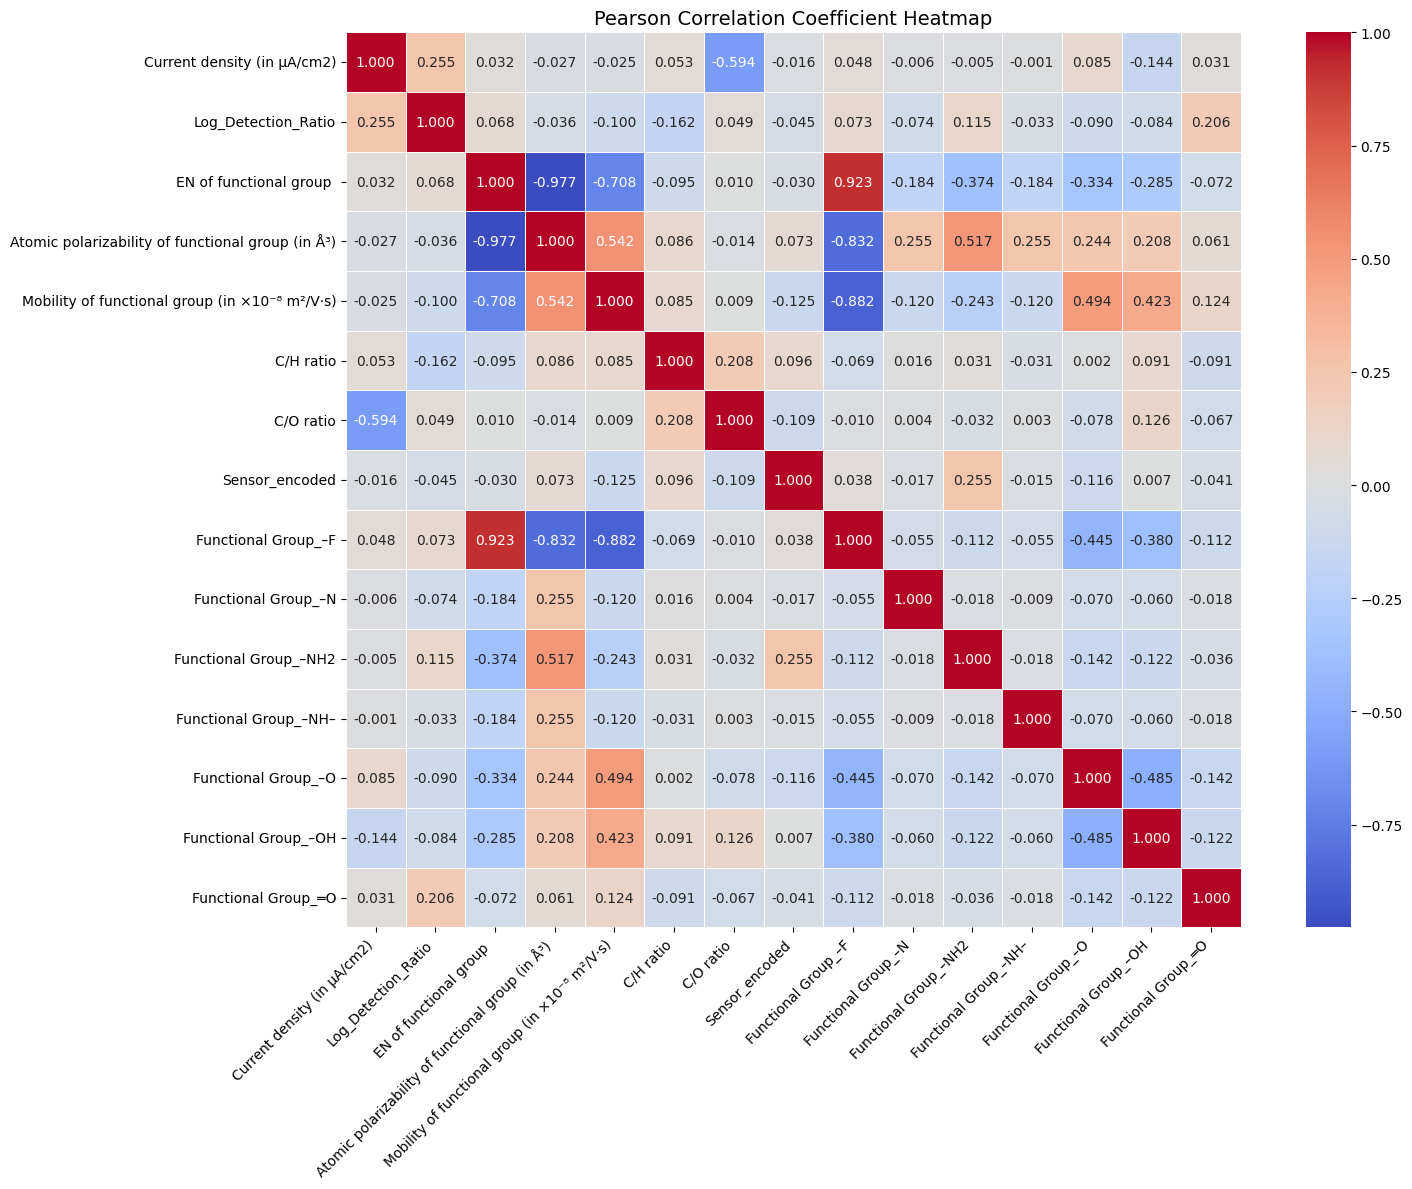

In [26]:
# Correlation matrix
corr_matrix = df.select_dtypes(include=[np.number]).corr(method="pearson")

# Plot heatmap
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation values
    fmt=".3f",           # 3 decimal places
    cmap="coolwarm",     # color scheme
    linewidths=0.5,
    square=True
)

plt.title("Pearson Correlation Coefficient Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("Pearson_correlation_heatmap_2.png", dpi=300, bbox_inches="tight")
plt.show()